# `to_stl`

The `to_stl` function converts a boolean voxel image into an STL object. Various methods for doing the conversion are available, and the returned result can be in a variety of formats.

In [27]:
import porespy as ps
import pyvista as pv
pv.set_jupyter_backend('static')

## `im`
The input image should be a `bool`.  The mesh will represent the `True` voxels.

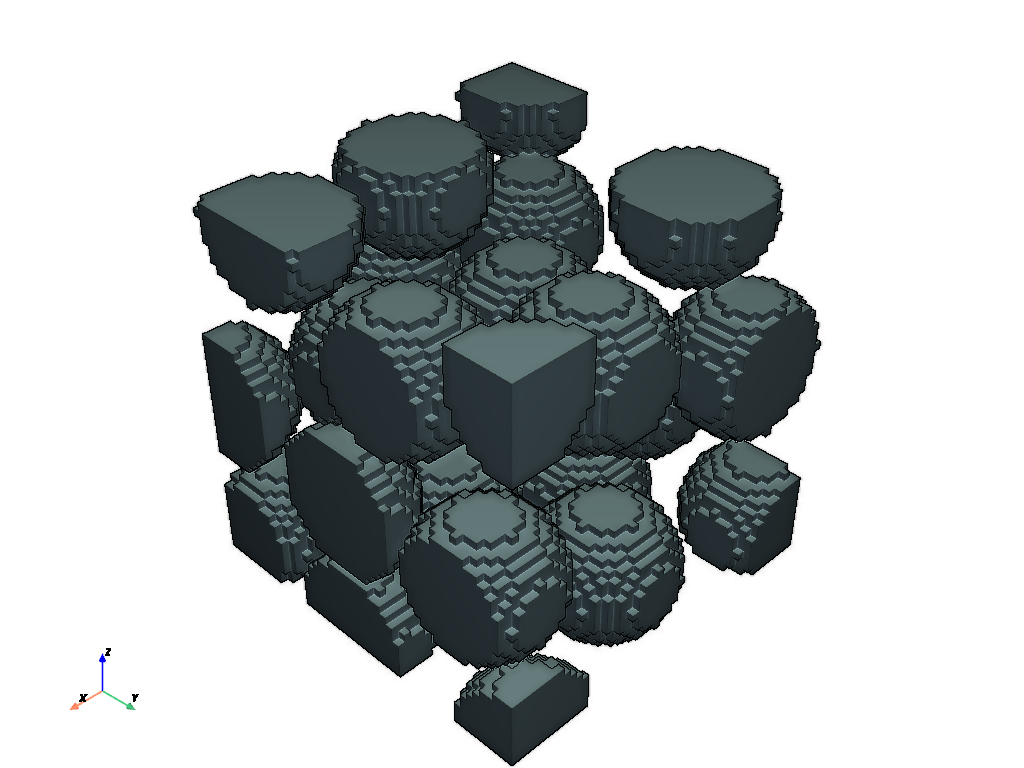

In [28]:
im = ps.generators.random_spheres([50, 50, 50], r=8, edges='extended')
mesh = ps.io.to_stl(im, fmt='pyvista')
pv.plot(mesh, eye_dome_lighting=True, jupyter_backend='static')

## `fmt`
The returned value is an object of the type specified by `fmt`.  Options are 'pyvista', 'meshio', 'opend3d', 'trimesh', 'skgraph' (aka 'vfn' for "vertices", "faces" and "vertex normals"), and 'openstl' (ada 'triangles').

In [29]:
mesh = ps.io.to_stl(im, fmt='trimesh')
print(mesh)

<trimesh.Trimesh(vertices.shape=(168360, 3), faces.shape=(56120, 3))>


## 'method'
The method used for create the STL mesh can be either 'direct', which corresponds exactly to the voxels, and 'marching-cubes' which has slightly smoother faces.

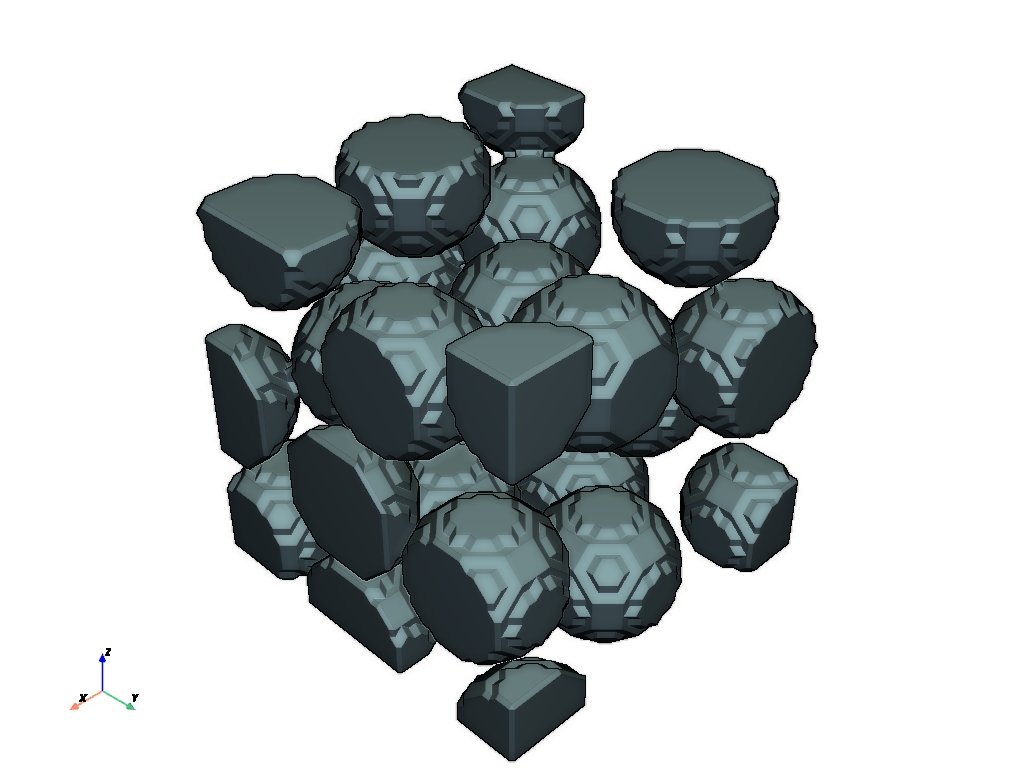

In [30]:
mesh = ps.io.to_stl(im, method='marching-cubes', fmt='pyvista')
pv.plot(mesh, eye_dome_lighting=True, jupyter_backend='static')

## `remove_duplicates`
This option, if set to `True` removes duplicate vertices and faces to reduce the size of the dataset.

In [31]:
mesh1 = ps.io.to_stl(im, method='marching-cubes', fmt='pyvista', remove_duplicates=False)
mesh2 = ps.io.to_stl(im, method='marching-cubes', fmt='pyvista', remove_duplicates=True)
print(mesh1)
print(mesh2)

PolyData (0x300af6320)
  N Cells:    56084
  N Points:   168252
  N Strips:   0
  X Bounds:   5.000e-01, 5.050e+01
  Y Bounds:   5.000e-01, 5.050e+01
  Z Bounds:   5.000e-01, 5.050e+01
  N Arrays:   0
PolyData (0x300a92b00)
  N Cells:    56084
  N Points:   28064
  N Strips:   0
  X Bounds:   5.000e-01, 5.050e+01
  Y Bounds:   5.000e-01, 5.050e+01
  Z Bounds:   5.000e-01, 5.050e+01
  N Arrays:   0


As can be seen the mesh has quite a lot fewer points after the duplicates are removed.